In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("/mnt/scratch/sameer/test_rosetta/Output/score.sc",
                 delim_whitespace=True, skiprows=1)
print(df.columns)
df

Index(['SCORE:', 'total_score', 'Grid_score', 'Transform_accept_ratio',
       'angle_constraint', 'atom_pair_constraint', 'chainbreak',
       'classic_grid_X', 'coordinate_constraint', 'dihedral_constraint',
       'dslf_ca_dih', 'dslf_cs_ang', 'dslf_ss_dih', 'dslf_ss_dst', 'fa_atr',
       'fa_dun', 'fa_elec', 'fa_pair', 'fa_rep', 'fa_sol', 'hbond_bb_sc',
       'hbond_lr_bb', 'hbond_sc', 'hbond_sr_bb', 'if_X_angle_constraint',
       'if_X_atom_pair_constraint', 'if_X_chainbreak',
       'if_X_coordinate_constraint', 'if_X_dihedral_constraint',
       'if_X_dslf_ca_dih', 'if_X_dslf_cs_ang', 'if_X_dslf_ss_dih',
       'if_X_dslf_ss_dst', 'if_X_fa_atr', 'if_X_fa_dun', 'if_X_fa_elec',
       'if_X_fa_pair', 'if_X_fa_rep', 'if_X_fa_sol', 'if_X_hbond_bb_sc',
       'if_X_hbond_lr_bb', 'if_X_hbond_sc', 'if_X_hbond_sr_bb', 'if_X_omega',
       'if_X_p_aa_pp', 'if_X_pro_close', 'if_X_ref', 'interface_delta_X',
       'ligand_is_touching_X', 'omega', 'p_aa_pp', 'pro_close', 'ref',
       't

,SCORE:,total_score,Grid_score,Transform_accept_ratio,angle_constraint,atom_pair_constraint,chainbreak,classic_grid_X,coordinate_constraint,dihedral_constraint,...,if_X_pro_close,if_X_ref,interface_delta_X,ligand_is_touching_X,omega,p_aa_pp,pro_close,ref,total_score_X,description
0,SCORE:,-874.071,-31.0,0.89,0.0,0.0,0.0,-25.0,0.668,0.0,...,0.0,0.0,-11.048,1.0,49.829,-40.282,1.235,-43.83,-25.0,temp_0001
1,SCORE:,-879.190,-31.0,0.91,0.0,0.0,0.0,-31.0,0.674,0.0,...,0.0,0.0,-15.450,1.0,49.512,-40.624,1.279,-43.83,-31.0,temp_0002
2,SCORE:,-869.596,-31.0,0.93,0.0,0.0,0.0,-28.0,0.194,0.0,...,0.0,0.0,-6.781,1.0,49.576,-40.664,1.258,-43.83,-28.0,temp_0003
3,SCORE:,-877.118,-31.0,0.95,0.0,0.0,0.0,-30.0,1.310,0.0,...,0.0,0.0,-14.916,1.0,49.439,-40.779,1.253,-43.83,-30.0,temp_0004
4,SCORE:,-877.399,-31.0,0.89,0.0,0.0,0.0,-31.0,1.096,0.0,...,0.0,0.0,-15.120,1.0,49.738,-40.688,1.272,-43.83,-31.0,temp_0005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,SCORE:,-875.311,-31.0,0.89,0.0,0.0,0.0,-30.0,0.640,0.0,...,0.0,0.0,-10.186,1.0,48.269,-40.546,1.260,-43.83,-30.0,temp_4996
4996,SCORE:,-869.279,-31.0,0.96,0.0,0.0,0.0,-28.0,0.556,0.0,...,0.0,0.0,-6.511,1.0,49.439,-40.836,1.252,-43.83,-28.0,temp_4997
4997,SCORE:,-868.173,-31.0,0.87,0.0,0.0,0.0,-26.0,0.483,0.0,...,0.0,0.0,-4.989,1.0,49.222,-40.678,1.291,-43.83,-26.0,temp_4998
4998,SCORE:,-870.432,-31.0,0.91,0.0,0.0,0.0,-27.0,0.405,0.0,...,0.0,0.0,-8.185,1.0,49.358,-40.703,1.287,-43.83,-27.0,temp_4999


Spearman r between total_score and interface_delta_X : 0.90


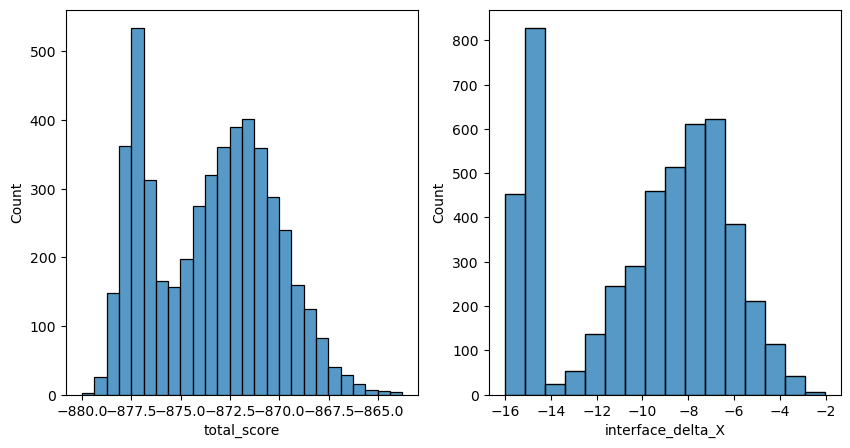

In [3]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
sns.histplot(df.total_score, ax=axs[0])
sns.histplot(df.interface_delta_X, ax=axs[1])


print(f"Spearman r between total_score and interface_delta_X : "
      f"{spearmanr(df.total_score, df.interface_delta_X).statistic:.2f}")
      
pass

In [4]:
np.random.seed(100)

In [5]:
sample_size = 4000
num_samples = 200

In [6]:
def pick_mininmum(arr, sample_size, arr2=None):
    """ Select sample_size elements of arr at random and return the minimum m
        if arr2 is not None, also return the value of arr2 in the same place as m
    """
    N = len(arr)
    sample_idxs = np.random.choice(np.arange(N), size=sample_size, replace=False)
    #print(sample_idxs)
    m = arr[sample_idxs].argmin()
    ret = arr[sample_idxs].iloc[m]
    if arr2 is not None:
        assert(len(arr) == len(arr2))
        ret = (ret, arr2[sample_idxs].iloc[m])
    return ret

In [7]:
all_results = []

for sample_size in (1, 5, 10, 100, 500, 1000, 2000):
    x_mins = np.zeros(num_samples, dtype=float)
    y_mins = np.zeros_like(x_mins)
    for i in range(num_samples):
        x_mins[i] = pick_mininmum(df.total_score, sample_size=sample_size)
        y_mins[i] = pick_mininmum(df.total_score, sample_size=sample_size)
    results_df = pd.DataFrame({"sample_size":np.repeat(sample_size, num_samples),
                               "i":np.arange(num_samples), "x_mins":x_mins, "y_mins":y_mins})    
    all_results.append(results_df)
all_results = pd.concat(all_results)

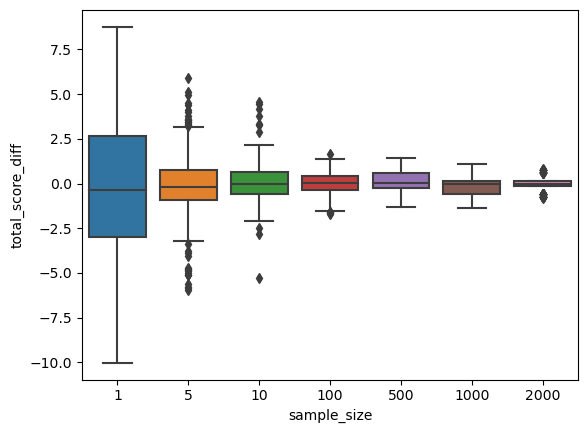

In [8]:
all_results["total_score_diff"] = all_results.y_mins - all_results.x_mins
sns.boxplot(all_results, x="sample_size", y="total_score_diff", )
pass

In [9]:
all_results = []

for sample_size in (1, 5, 10, 100, 500, 1000, 2000):
    x_mins = np.zeros(num_samples, dtype=float)
    y_mins = np.zeros_like(x_mins)
    for i in range(num_samples):
        x_mins[i] = pick_mininmum(df.total_score, sample_size=sample_size, 
                                      arr2=df.interface_delta_X)[1]
        y_mins[i] = pick_mininmum(df.total_score, sample_size=sample_size,
                                     arr2=df.interface_delta_X)[1]
    results_df = pd.DataFrame({"sample_size":np.repeat(sample_size, num_samples),
                               "i":np.arange(num_samples), "x_mins":x_mins, "y_mins":y_mins})    
    all_results.append(results_df)
all_results = pd.concat(all_results)

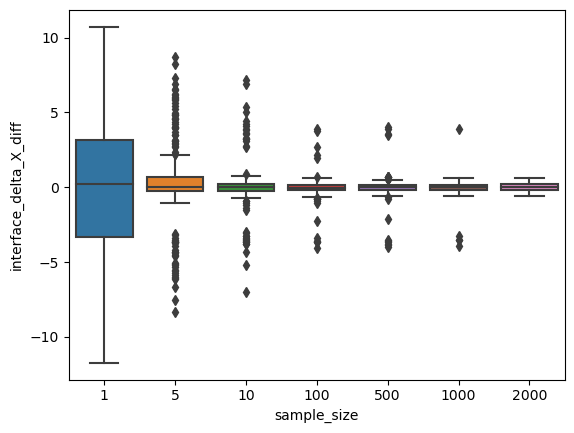

In [10]:
all_results["interface_delta_X_diff"] = all_results.y_mins - all_results.x_mins
sns.boxplot(all_results, x="sample_size", y="interface_delta_X_diff", )
pass

## Folding funnel for docking

In [11]:
rmsd_0 = pd.read_csv("/mnt/scratch/sameer/test_rosetta/Output_Temp_0/rmsd_to_best_model.sc",
                 delim_whitespace=True, skiprows=1)
len(rmsd_0)

5000

In [12]:
rmsd_5 = pd.read_csv("/mnt/scratch/sameer/test_rosetta/Output_Temp_5/rmsd_to_best_model.sc",
                 delim_whitespace=True, skiprows=1)
len(rmsd_5)

5000

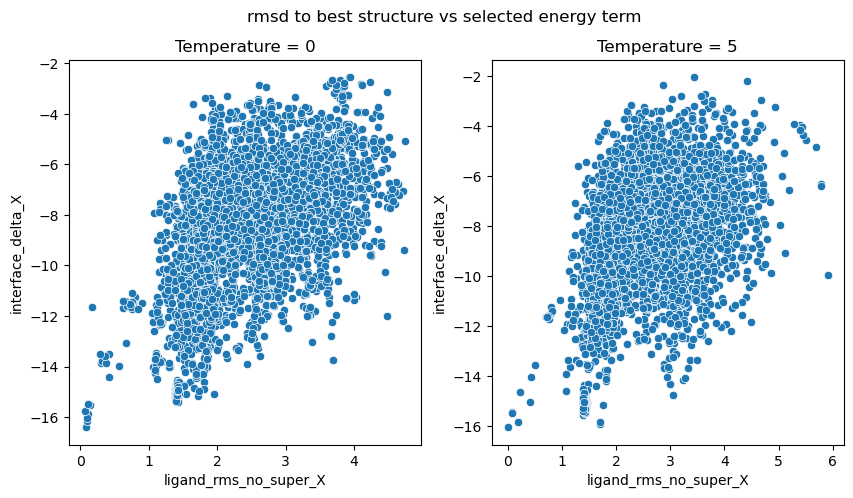

In [13]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
fig.suptitle("rmsd to best structure vs selected energy term")

ax = axs[0]
sns.scatterplot(x=rmsd_0.ligand_rms_no_super_X, y=rmsd_0.interface_delta_X, ax=ax)
ax.set_title("Temperature = 0")

ax = axs[1]
sns.scatterplot(x=rmsd_5.ligand_rms_no_super_X, y=rmsd_5.interface_delta_X, ax=ax)
ax.set_title("Temperature = 5")

pass